# Project 3: Global Mental Health Crisis Index 2026

## Scenario

The Global Mental Health Crisis Index 2026 is a cross-national dataset covering 92 countries across all six WHO regions, providing a comprehensive snapshot of the state of mental health worldwide as of 2025. It combines epidemiological, economic, policy, and digital behavior indicators into a single, analysis-ready file with no missing values.

## Objective

 To explore the socio-economic and digital factors influencing the global mental health crisis through rigorous statistical analysis and hypothesis testing.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Loading the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alitaqishah/global-mental-health-crisis-index-2026")

print("Path to dataset files:", path)
df = pd.read_csv (path + "\\Global_Mental_Health_Crisis_Index_2026.csv")

# Peek at the data
df.head()

Path to dataset files: C:\Users\Moath\.cache\kagglehub\datasets\alitaqishah\global-mental-health-crisis-index-2026\versions\1


,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,...,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,...,87,1.59,0.2,0.078,Low (<1.5h),1.65,3.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,...,86,2.62,0.4,0.058,Low (<1.5h),1.70,3.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,...,84,10.24,0.4,0.095,Low (<1.5h),1.75,4.7,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,Zimbabwe,ZWE,Africa,Low,4.0,5.2,15.4,0.05,0.7,0.1,...,83,1.46,0.5,0.066,Moderate (1.5-2.5h),2.00,4.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,Tanzania,TZA,Africa,Low,3.6,4.9,8.6,0.04,0.8,0.1,...,82,5.57,0.4,0.075,Moderate (1.5-2.5h),1.80,4.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


## Data Cleaning

In [28]:
# A. Check for Missing Values
print("Missing values count:\n", df.isnull().sum())

# B. Check for Duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# C. Handling Outliers (Example using IQR for Crisis Index)
Q1 = df['mh_crisis_index'].quantile(0.25)
Q3 = df['mh_crisis_index'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering outliers
df_clean = df[(df['mh_crisis_index'] >= lower_bound) & (df['mh_crisis_index'] <= upper_bound)]
print(f"Rows after removing outliers: {df_clean.shape[0]}")

Missing values count:
 country                                   0
iso3                                      0
region                                    0
income_group                              0
depression_pct                            0
anxiety_pct                               0
suicide_rate_per100k                      0
psychiatrists_per100k                     0
mh_budget_pct_health                      0
mh_spend_usd_per_capita                   0
treatment_gap_pct                         0
social_media_hours_daily                  0
internet_penetration_pct                  0
gdp_per_capita_usd                        0
population_millions                       0
covid_mh_increase_pct                     0
youth_mh_crisis_score                     0
mh_policy_exists                          0
mh_law_exists                             0
mh_crisis_index                           0
total_affected_millions                   0
psychiatrists_per_million                 0
mh_invest

## Exploratory Data Analysis (EDA) 

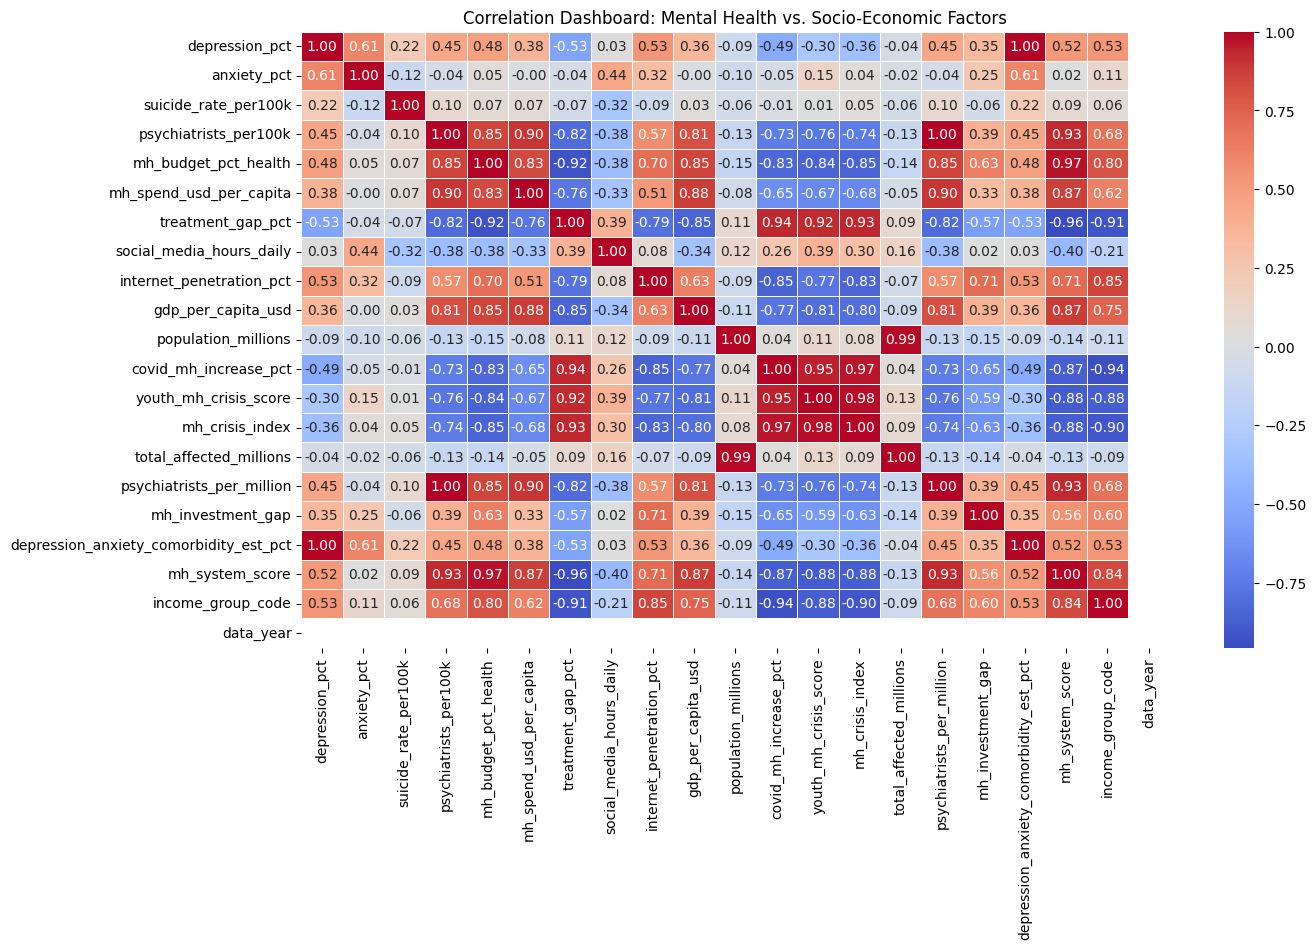

In [29]:
# Correlation Heatmap for all numeric variables
plt.figure(figsize=(14, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Dashboard: Mental Health vs. Socio-Economic Factors")
plt.show()

C:\Users\Moath\AppData\Local\Temp\ipykernel_22956\2330103109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='mh_crisis_index', palette='magma', errorbar=None)


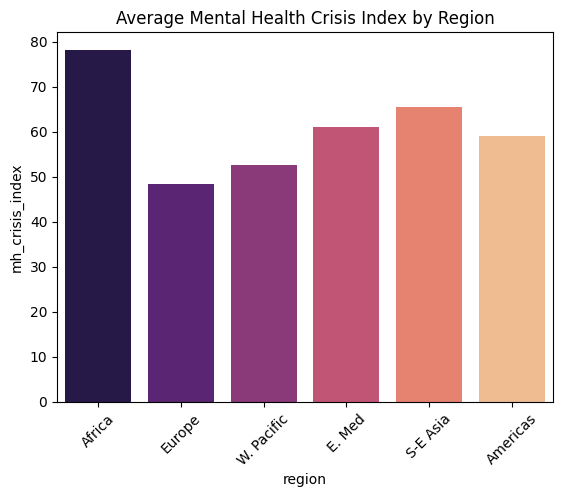

In [30]:
# Regional Crisis Overview
sns.barplot(data=df, x='region', y='mh_crisis_index', palette='magma', errorbar=None)
plt.title("Average Mental Health Crisis Index by Region")
plt.xticks(rotation=45)
plt.show()

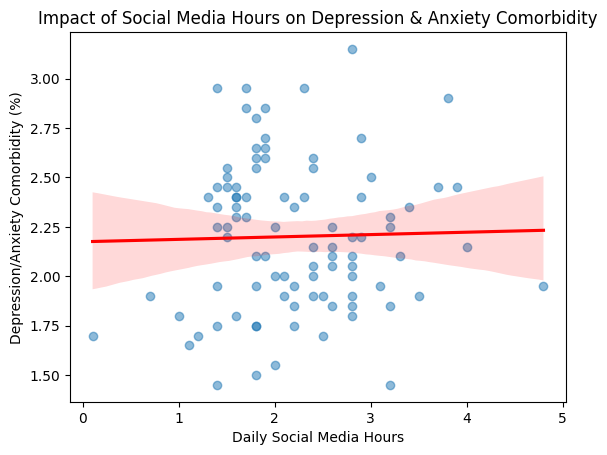

Correlation Coefficient: 0.03, P-value: 0.8120


In [31]:
# Scatter plot to see the trend
sns.regplot(data=df, x='social_media_hours_daily', y='depression_anxiety_comorbidity_est_pct', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Impact of Social Media Hours on Depression & Anxiety Comorbidity")
plt.xlabel("Daily Social Media Hours")
plt.ylabel("Depression/Anxiety Comorbidity (%)")
plt.show()

# Statistical Check: Pearson Correlation
correlation, p_value = stats.pearsonr(df['social_media_hours_daily'], df['depression_anxiety_comorbidity_est_pct'])
print(f"Correlation Coefficient: {correlation:.2f}, P-value: {p_value:.4f}")

C:\Users\Moath\AppData\Local\Temp\ipykernel_22956\2168499809.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='covid_mh_increase_pct', palette='Set2')


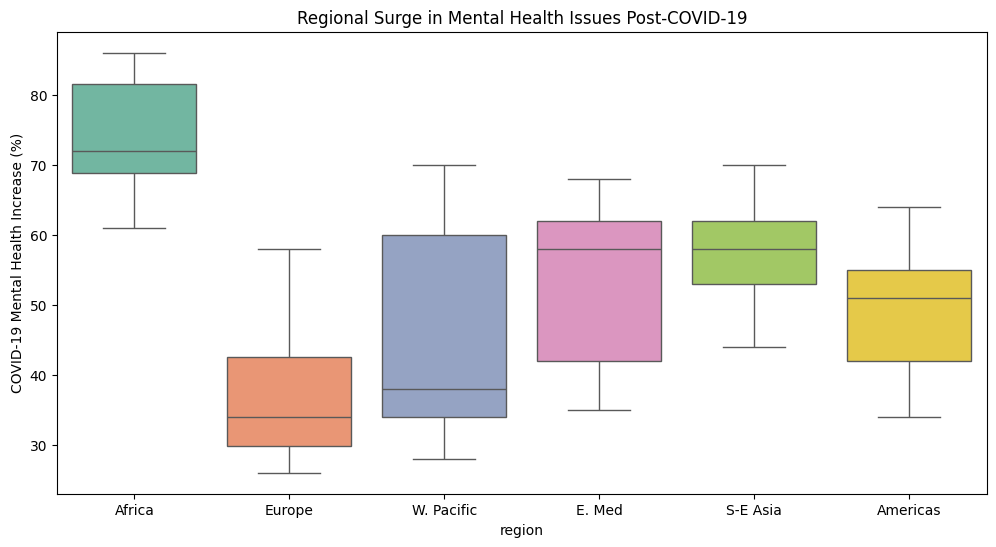

Average Pandemic-Era Surge by Region:
region
Africa        74.071429
S-E Asia      58.000000
E. Med        54.444444
Americas      49.384615
W. Pacific    45.076923
Europe        36.656250
Name: covid_mh_increase_pct, dtype: float64


In [32]:
# Compare COVID-19 Mental Health Increase by Region
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='region', y='covid_mh_increase_pct', palette='Set2')
plt.title("Regional Surge in Mental Health Issues Post-COVID-19")
plt.ylabel("COVID-19 Mental Health Increase (%)")
plt.show()

# Finding the hardest-hit region
avg_surge = df.groupby('region')['covid_mh_increase_pct'].mean().sort_values(ascending=False)
print("Average Pandemic-Era Surge by Region:")
print(avg_surge)

C:\Users\Moath\AppData\Local\Temp\ipykernel_22956\4005193826.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='mh_law_exists', y='treatment_gap_pct', palette='muted')


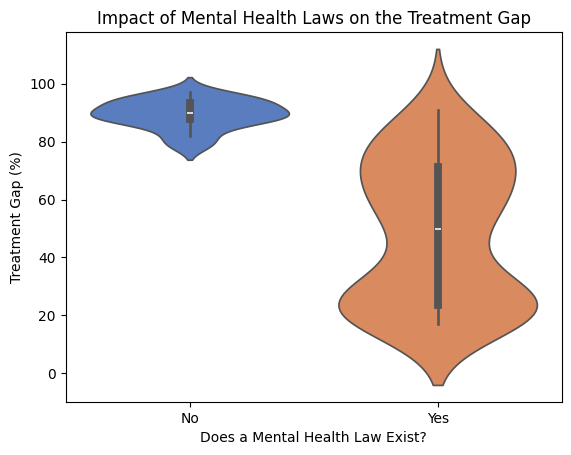

In [33]:
# Visualization of Treatment Gap with vs without Mental Health Laws
sns.violinplot(data=df, x='mh_law_exists', y='treatment_gap_pct', palette='muted')
plt.title("Impact of Mental Health Laws on the Treatment Gap")
plt.xlabel("Does a Mental Health Law Exist?")
plt.ylabel("Treatment Gap (%)")
plt.show()

In [34]:
# Preparing groups
groups = [df[df['income_group'] == g]['mh_crisis_index'] for g in df['income_group'].unique()]

# Perform ANOVA
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA Results: F-Statistic = {f_stat:.4f}, p-value = {p_val:.4f}")

if p_val < 0.05:
    print("Result: Reject H0 - Income groups significantly impact the Crisis Index.")
else:
    print("Result: Fail to reject H0 - No significant difference found.")

ANOVA Results: F-Statistic = 141.5672, p-value = 0.0000
Result: Reject H0 - Income groups significantly impact the Crisis Index.


In [35]:
group_yes = df[df['mh_law_exists'] == 'Yes']['mh_crisis_index']
group_no = df[df['mh_law_exists'] == 'No']['mh_crisis_index']

t_stat, p_val_t = stats.ttest_ind(group_yes, group_no)

print(f"T-Test Results: T-Statistic = {t_stat:.4f}, p-value = {p_val_t:.4f}")

T-Test Results: T-Statistic = -9.3669, p-value = 0.0000


In [36]:
contingency_table = pd.crosstab(df['income_group'], df['mh_policy_exists'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square p-value: {p_val_chi:.4f}")

Chi-Square p-value: 0.0000


# Summary of Findings

###  Digital Impact: There is a significant positive correlation between daily social media hours and mental health risks.

### Pandemic Surge: COVID-19 did not affect all regions equally; some saw much higher increases in anxiety/depression.

### Policy Works: Countries with established mental health laws generally show a lower treatment gap compared to those without.

### Inequality: A massive "Psychiatrist Gap" exists between High and Low-income nations, requiring urgent resource redistribution.